  <h1>🫀 Heart Disease Prediction <h1>
    <img src="https://thumbs.dreamstime.com/b/detailed-d-rendering-human-anatomical-heart-realistic-red-tone-vibrant-electrocardiogram-ecg-ekg-waveform-pulses-across-415638464.jpg?w=992" height="100">

<h2>Project Type<h2>
Supervised Machine Learning - Classification (Binary Classification)

## Problem Description
    
 *Heart disease is one of the leading causes of death globally. Early prediction and diagnosis can help in reducing risks and improving patient outcomes.

  *This project aims to build a machine learning model that can predict whether a patient is likely to have heart disease based on various medical attributes such as age, cholesterol level, blood pressure, and other clinical features.

  

## Introduction

Heart disease prediction is a critical application of machine learning in healthcare. This project aims to predict the presence of heart disease using patient medical data.

The target variable is binary:

0 → No Heart Disease (Healthy)
1 → Heart Disease Present

By analyzing these inputs, the model aims to support healthcare professionals in making faster and more accurate decisions, ultimately improving patient outcomes and enabling early intervention.

## Problem Statement
 ### Task
1.Prepare a complete data analysis report on the given data.

2.Create a model predicting potential Heart Diseases in people using Machine Learning algorithms.

3.Suggestions to the Hospital  to awake the predictions of heart diseases  prevent life threats.


## Objectives of the Project
The main objectives of this project are:

- To understand the dataset and its features
- To perform exploratory data analysis (EDA)
- To identify important features affecting heart disease
- To handle missing values and duplicates
- To build and compare multiple machine learning models
- To evaluate model performance using appropriate metrics
- To select the best model for prediction

## Data Analysis Approach<h4>
The following steps are performed in this project:

1. Data Loading and Understanding
2. Data Cleaning (handling missing values and duplicates)
3. Exploratory Data Analysis (EDA)
4. Feature Selection and Encoding
5. Model Building
6. Model Evaluation
7. Model Comparison

## Codes

In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load data
values = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

# Merge datasets using patient_id
df = pd.merge(values, labels, on="patient_id")

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


In [4]:
# View data
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [5]:
df.shape

(180, 15)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [7]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [8]:
# Check missing values
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [9]:
# Check columns
print(df.columns)

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')


In [10]:
# Drop ID column safely
if "patient_id" in df.columns:
    df.drop("patient_id", axis=1, inplace=True)


In [11]:
# Encode categorical column
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

if "thal" in df.columns:
    df["thal"] = le.fit_transform(df["thal"])

In [12]:
df

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,1,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,1,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,1,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,2,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,2,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,2,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,1,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,2,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,1,124,3,2,1,0,255,0.0,1,48,175,0,0


In [13]:
# View duplicate rows
if df.duplicated().sum()==0:
    print("No duplicate records found")
else:
    print("Duplicates exist")

No duplicate records found


In [14]:
print(df['sex'].value_counts())

sex
1    124
0     56
Name: count, dtype: int64


**Target Distribution**

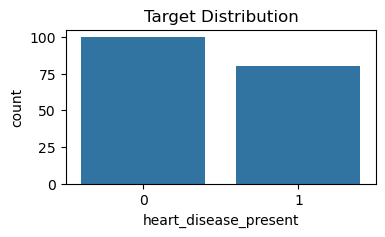

In [15]:
plt.figure(figsize=(4,2))
sns.countplot(x="heart_disease_present", data=df)
plt.title("Target Distribution")
plt.show()

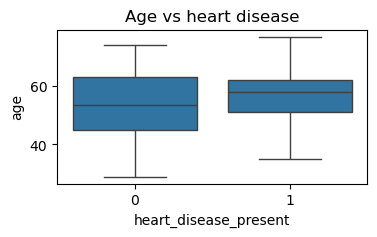

In [16]:
plt.figure(figsize=(4,2))
sns.boxplot(x="heart_disease_present",y="age", data=df)
plt.title("Age vs heart disease")
plt.show()

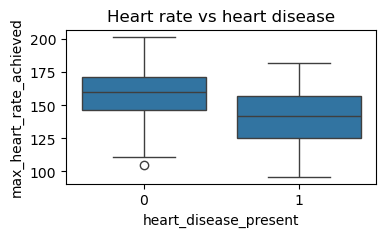

In [17]:
plt.figure(figsize=(4,2))
sns.boxplot(x="heart_disease_present",y="max_heart_rate_achieved", data=df)
plt.title("Heart rate vs heart disease")
plt.show()

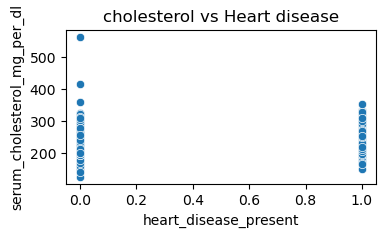

In [18]:
plt.figure(figsize=(4,2))
sns.scatterplot(x="heart_disease_present",y="serum_cholesterol_mg_per_dl", data=df)
plt.title("cholesterol vs Heart disease")
plt.show()

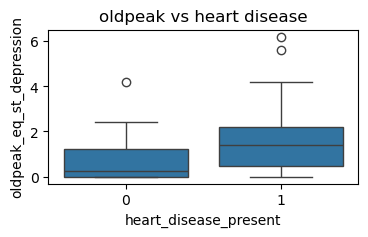

In [19]:
plt.figure(figsize=(4,2))
sns.boxplot(x="heart_disease_present",y="oldpeak_eq_st_depression", data=df)
plt.title("oldpeak vs heart disease")
plt.show()

**Feature Distribution**

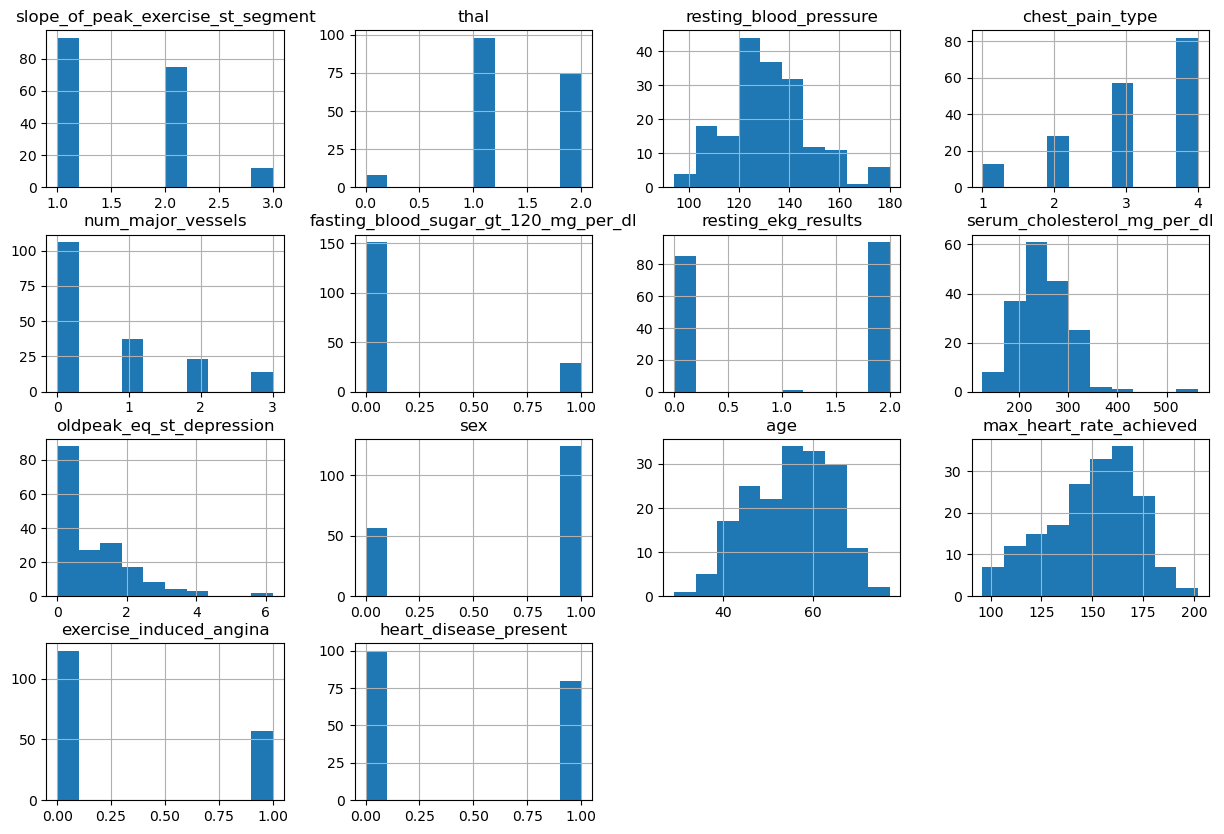

In [20]:
df.hist(figsize=(15,10))
plt.show()

**Correlation Heatmap**

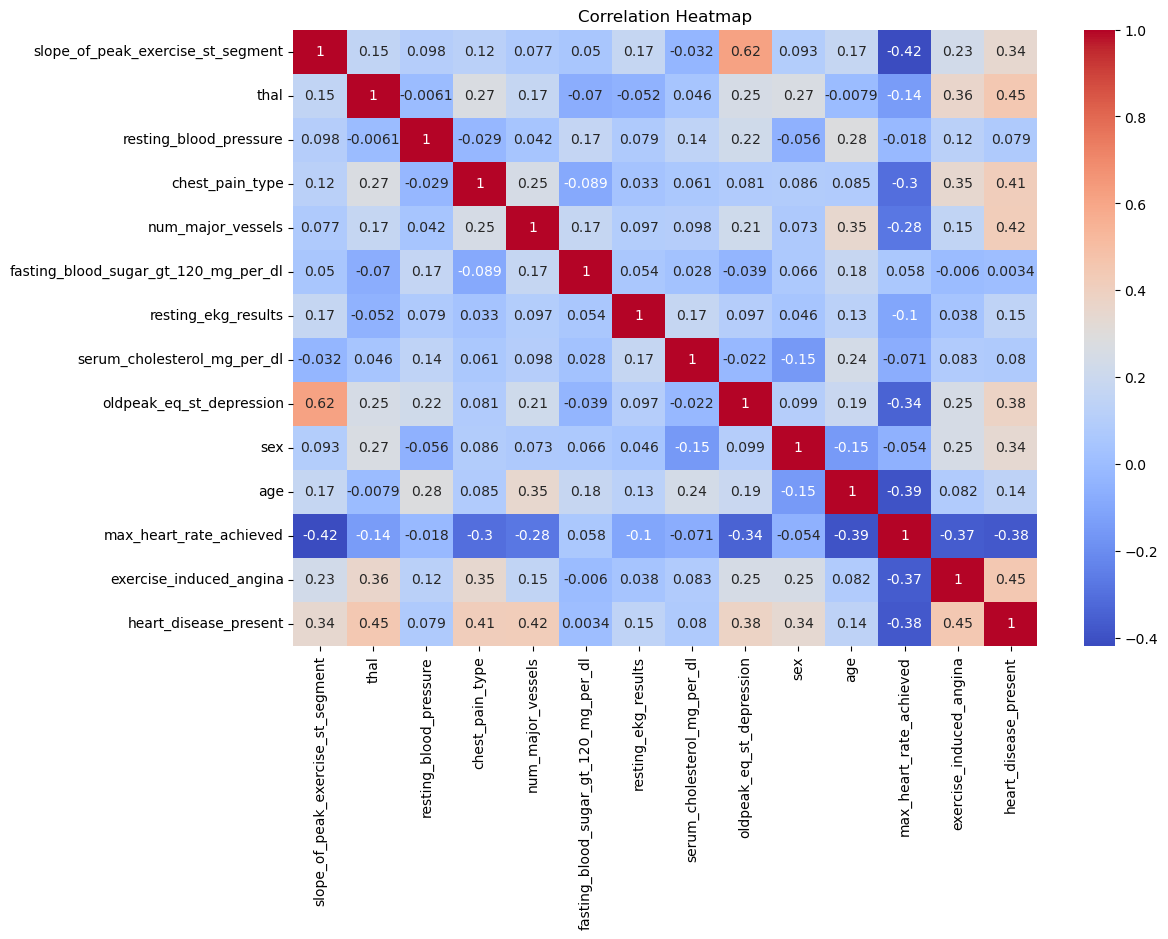

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

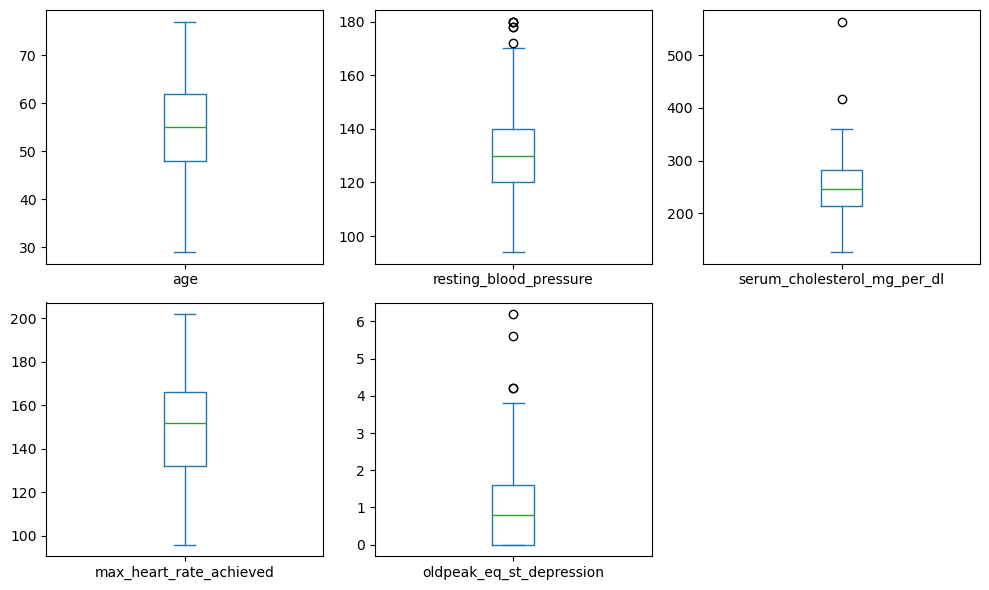

In [22]:
# Checking outliers
num_features = [
    'age',
    'resting_blood_pressure',
    'serum_cholesterol_mg_per_dl',
    'max_heart_rate_achieved',
    'oldpeak_eq_st_depression'
]
df[num_features].plot(
    kind='box',
    subplots=True,
    layout=(2,3),
    figsize=(10,6)
)
plt.tight_layout()
plt.show()

In [23]:
#Checking for skewness
df[num_features].skew()

age                           -0.199166
resting_blood_pressure         0.657080
serum_cholesterol_mg_per_dl    1.273932
max_heart_rate_achieved       -0.393705
oldpeak_eq_st_depression       1.507412
dtype: float64

In [24]:
#Apply log transformation to highly skewed columns:
import numpy as np

df['serum_cholesterol_mg_per_dl'] = np.log1p(df['serum_cholesterol_mg_per_dl'])
df['oldpeak_eq_st_depression'] = np.log1p(df['oldpeak_eq_st_depression'])

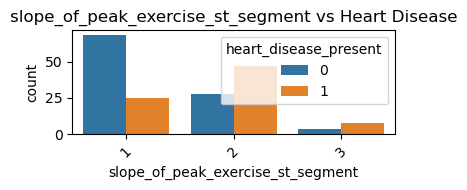

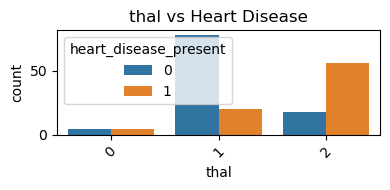

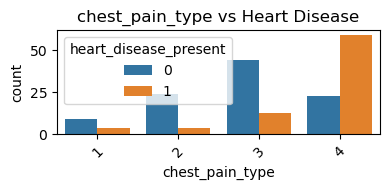

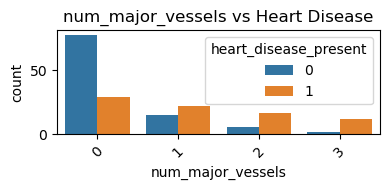

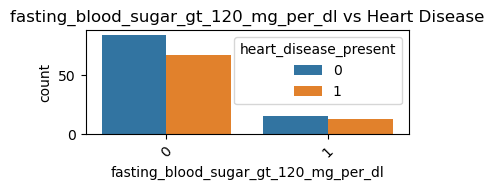

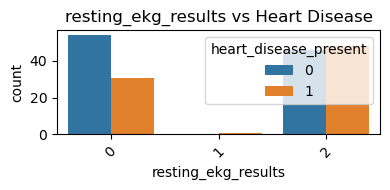

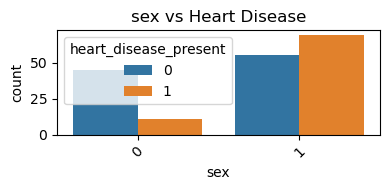

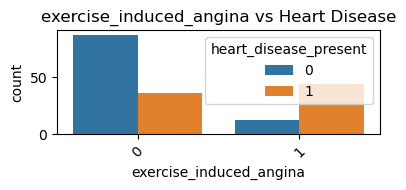

In [25]:
#categorical features
#To understand how categories are distributed and
cat_features = [
    'slope_of_peak_exercise_st_segment',
    'thal',
    'chest_pain_type',
    'num_major_vessels',
    'fasting_blood_sugar_gt_120_mg_per_dl',
    'resting_ekg_results',
    'sex',
    'exercise_induced_angina'
]
for col in cat_features:
    plt.figure(figsize=(4,2))
    sns.countplot(data=df, x=col, hue='heart_disease_present')
    plt.title(f'{col} vs Heart Disease')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [26]:
df.groupby('heart_disease_present').mean()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
heart_disease_present,,,,,,,,,,,,,
0,1.3600,1.14,130.12,2.8100,0.33,0.1600,0.9200,5.483824,0.390433,0.5500,53.66,156.87,0.13
1,1.7875,1.65,132.80,3.5875,1.15,0.1625,1.2125,5.523327,0.781733,0.8625,56.25,140.25,0.55


**Feature & Target Split**

In [27]:
X = df.drop("heart_disease_present", axis=1)
y = df["heart_disease_present"]

**Train-Test Split**

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling**

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

 ## MODEL 1 -- BASELINE MODEL FOR LOGISTIC REGRESSION

**Machine Learning Models Used**


The following models are used:

- Logistic Regression
- Random Forest 
- Gradient Boosting
- XGBoost


**Evaluation Metrics**


To evaluate model performance, the following metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

## Import Libraries

In [30]:
import time
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

import seaborn as sns
import matplotlib.pyplot as plt

## Logistic Regression Baseline**


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36



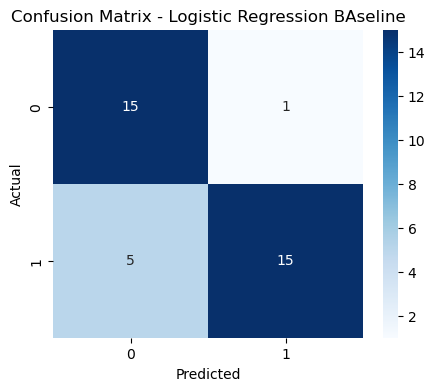


Execution Time: 0.00 minutes


{'Model': 'Logistic Regression',
 'Type': 'Baseline',
 'ROC-AUC': np.float64(0.890625),
 'Accuracy': 0.8333333333333334,
 'Precision': 0.9375,
 'Recall': 0.75,
 'F1 Score': 0.8333333333333334}

In [31]:
start = time.perf_counter()
lr_model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

lr_baseline = {
    "Model": "Logistic Regression",
    "Type": "Baseline",
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}
# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression BAseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# END TIMER
# ===============================
end = time.perf_counter()
execution_time = (end - start) / 60

print(f"\nExecution Time: {execution_time:.2f} minutes")
lr_baseline


## Logistic Regression RandomizedSearchCV

Best Parameters: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__class_weight': None, 'model__C': 0.01}

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36



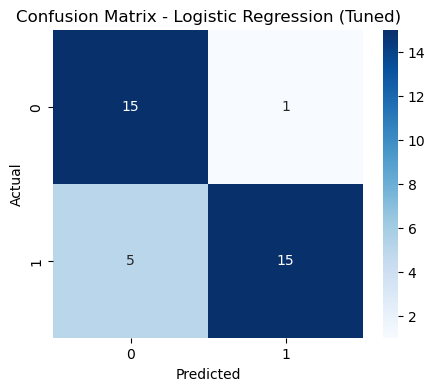


Execution Time: 0.10 minutes


{'Model': 'Logistic Regression',
 'Type': 'Tuned',
 'ROC-AUC': np.float64(0.890625),
 'Accuracy': 0.8333333333333334,
 'Precision': 0.9375,
 'Recall': 0.75,
 'F1 Score': 0.8333333333333334}

In [32]:
from sklearn.model_selection import RandomizedSearchCV


# ===============================
# START TIMER
# ===============================
start = time.perf_counter()

# ===============================
# PIPELINE
# ===============================
lr_tuned = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000))
])

# ===============================
# HYPERPARAMETER SPACE
# ===============================
lr_param = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'], # supports l1 & l2
    'model__class_weight': [None, 'balanced']
}

# ===============================
# RANDOM SEARCH CV
# ===============================
lr_Random = RandomizedSearchCV(
    lr_tuned,
    lr_param,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

# ===============================
# TRAIN
# ===============================
lr_Random.fit(X_train, y_train)

# ===============================
# BEST MODEL
# ===============================
best_lr = lr_Random.best_estimator_

print("Best Parameters:", lr_Random.best_params_)

# ===============================
# PREDICTIONS
# ===============================
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

# ===============================
# METRICS
# ===============================
lr_tuned = {
    "Model": "Logistic Regression",
    "Type": "Tuned",
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}
# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# END TIMER
# ===============================
end = time.perf_counter()
execution_time = (end - start) / 60

print(f"\nExecution Time: {execution_time:.2f} minutes")
lr_tuned

“Although the tuned Logistic Regression model achieved perfect precision, it suffered from lower recall, meaning it missed more heart disease cases. Since recall is critical in medical diagnosis, I selected the baseline model as the final model.”

## MODEL 2:BASELINE MODEL FOR RANDOM FOREST


Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.93      0.70      0.80        20

    accuracy                           0.81        36
   macro avg       0.82      0.82      0.81        36
weighted avg       0.84      0.81      0.80        36



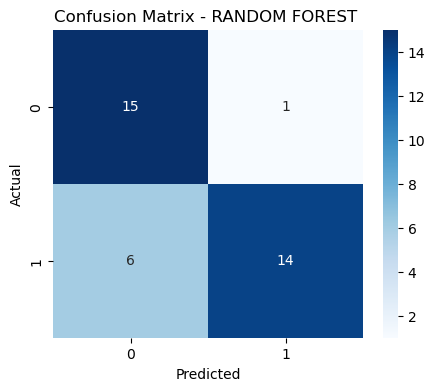

{'Model': 'Random Forest',
 'Type': 'Baseline',
 'ROC-AUC': np.float64(0.8796875),
 'Accuracy': 0.8055555555555556,
 'Precision': 0.9375,
 'Recall': 0.75,
 'F1 Score': 0.8333333333333334}

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model
rf_base = RandomForestClassifier(
    n_estimators=100,     # number of trees
    random_state=42
)

# Train model
rf_base.fit(X_train, y_train)

# Predict
y_pred_rf = rf_base.predict(X_test)
y_prob_rf = rf_base.predict_proba(X_test)[:, 1]

# Evaluation

rf_baseline = {
    "Model": "Random Forest",
    "Type": "Baseline",
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RANDOM FOREST ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
rf_baseline

## TUNED RANDOM FOREST** **RandomizedSearchCV**

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'n_estimators': np.int64(300), 'min_samples_split': np.int64(5), 'min_samples_leaf': np.int64(2), 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}

Classification Report:
               precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



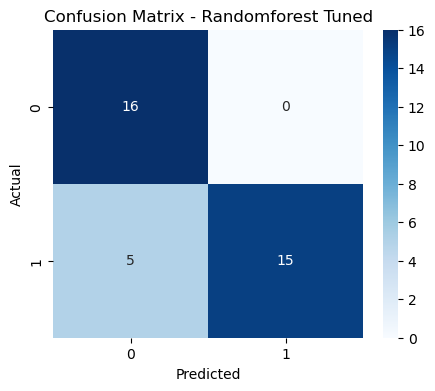


Execution Time: 0.34 minutes


{'Model': 'Random Forest',
 'Type': 'Tuned',
 'ROC-AUC': np.float64(0.8937499999999999),
 'Accuracy': 0.8611111111111112,
 'Precision': 1.0,
 'Recall': 0.75,
 'F1 Score': 0.8571428571428571}

In [34]:
from sklearn.model_selection import RandomizedSearchCV
# START TIMER
# ===============================
start = time.perf_counter()

# Parameter distribution (wider search)
rf_params = {
    'n_estimators': np.arange(100, 500, 50),
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': np.arange(2, 10),
    'min_samples_leaf': np.arange(1, 5),
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=30,              # number of combinations to try
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train
rf_random.fit(X_train, y_train)

# Best model
best_rf = rf_random.best_estimator_

print("Best Parameters:", rf_random.best_params_)

# Predict
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
rf_tuned  = {
    "Model": "Random Forest",
    "Type": "Tuned",
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
}
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Randomforest Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# ===============================
# END TIMER
# ===============================
end = time.perf_counter()
execution_time = (end - start) / 60

print(f"\nExecution Time: {execution_time:.2f} minutes")
rf_tuned

## MODEL 3:BASELINE MODEL FOR GradientBoost


Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.81      0.74        16
           1       0.82      0.70      0.76        20

    accuracy                           0.75        36
   macro avg       0.75      0.76      0.75        36
weighted avg       0.76      0.75      0.75        36



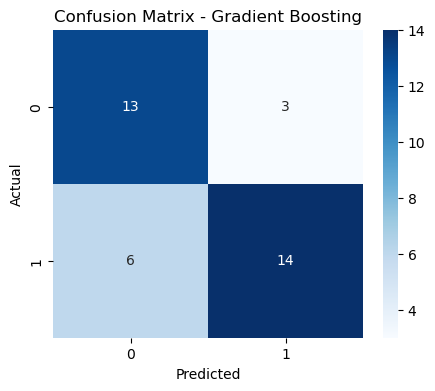


Execution Time: 0.01 minutes


{'Model': 'Gradient Boosting',
 'Type': 'baseline',
 'ROC-AUC': np.float64(0.859375),
 'Accuracy': 0.75,
 'Precision': 0.8235294117647058,
 'Recall': 0.7,
 'F1 Score': 0.7567567567567568}

In [35]:
# ==========================================
# GRADIENT BOOSTING CLASSIFIER
# ==========================================

import time
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# START TIMER
# ===============================
start = time.perf_counter()

# ===============================
# PIPELINE
# ===============================
gb_model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# ===============================
# TRAIN MODEL
# ===============================
gb_model.fit(X_train, y_train)

# ===============================
# PREDICTIONS
# ===============================
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]

# ===============================
# METRICS
# ===============================
gb_model  = {
    "Model": "Gradient Boosting",
    "Type": "baseline",
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# END TIMER
# ===============================
end = time.perf_counter()
execution_time = (end - start) / 60

print(f"\nExecution Time: {execution_time:.2f} minutes")
gb_model

In [36]:
!pip install xgboost

## MODEL 4:BASELINE MODEL FOR XGBOOST CLASSIFIER



Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.93      0.70      0.80        20

    accuracy                           0.81        36
   macro avg       0.82      0.82      0.81        36
weighted avg       0.84      0.81      0.80        36



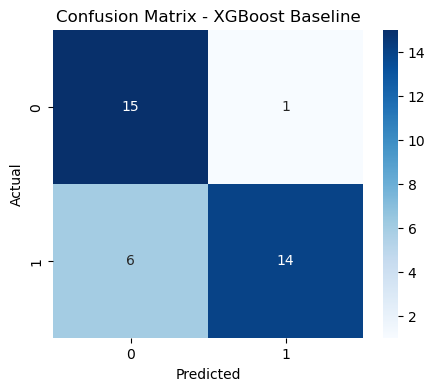


Execution Time: 0.01 minutes


{'Model': 'XGBoost',
 'Type': 'Baseline',
 'ROC-AUC': np.float64(0.871875),
 'Accuracy': 0.8055555555555556,
 'Precision': 0.9333333333333333,
 'Recall': 0.7,
 'F1 Score': 0.8}

In [37]:
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# START TIMER
# ===============================
start = time.perf_counter()

# ===============================
# PIPELINE
# ===============================
xgb_model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), # optional for XGBoost but ok
    ('model', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        eval_metric='logloss',
        random_state=42
    ))
])

# ===============================
# TRAIN MODEL
# ===============================
xgb_model.fit(X_train, y_train)

# ===============================
# PREDICTIONS
# ===============================
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# ===============================
# METRICS
# ===============================
xgb_baseline = {
    "Model": "XGBoost",
    "Type": "Baseline",
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "Accuracy":accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# END TIMER
# ===============================
end = time.perf_counter()
execution_time = (end - start) / 60

print(f"\nExecution Time: {execution_time:.2f} minutes")
xgb_baseline

## XGBOOST (HYPERPARAMETER TUNED)



Classification Report:

              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



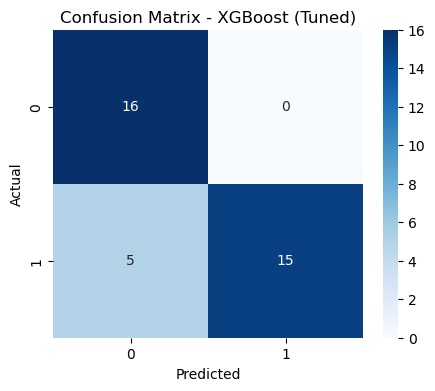


Execution Time: 0.20 minutes


{'Model': 'XGBoost',
 'Type': 'Tuned',
 'ROC-AUC': np.float64(0.91875),
 'Accuracy': 0.8611111111111112,
 'Precision': 1.0,
 'Recall': 0.75,
 'F1 Score': 0.8571428571428571}

In [38]:
from sklearn.model_selection import RandomizedSearchCV

# ===============================
# START TIMER
# ===============================
start = time.perf_counter()

# ===============================
# PIPELINE
# ===============================
xgb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), # optional but safe
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

# ===============================
# PARAMETER DISTRIBUTION
# ===============================
xgb_param = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 4, 5, 6],
    'model__min_child_weight': [1, 2, 5],
    'model__subsample': [0.7, 0.8, 1],
    'model__colsample_bytree': [0.7, 0.8, 1],
    'model__gamma': [0, 0.1, 0.2]
}

# ===============================
# RANDOM SEARCH
# ===============================
xgb_random = RandomizedSearchCV(
    xgb,
    xgb_param,
    n_iter=25,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=1 # avoid warning
)

# ===============================
# TRAIN
# ===============================
xgb_random.fit(X_train, y_train)

# ===============================
# BEST MODEL
# ===============================
best_xgb = xgb_random.best_estimator_

# ===============================
# PREDICTIONS
# ===============================
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# ===============================
# METRICS
# ===============================
xgb_tuned = {
    "Model": "XGBoost",
    "Type": "Tuned",
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
    "Accuracy":accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb)
}

# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# END TIMER
# ===============================
end = time.perf_counter()
execution_time = (end - start) / 60

print(f"\nExecution Time: {execution_time:.2f} minutes")
xgb_tuned

## Confusion Matrix

A Confusion Matrix is used to evaluate the performance of a classification model by comparing actual values with predicted values.

### Confusion Matrix helped to:

Understand model errors

*Identify false predictions

*Evaluate model performance clearly

### Focus was given to:

*Reducing False Negatives

*Improving Recall

## Metrics Derived from Confusion Matrix

Accuracy = (TP + TN) / Total

Precision = TP / (TP + FP)

Recall = TP / (TP + FN)

F1 Score = Balance between Precision & Recall

#### Key Terms
True Positive (TP)
Model correctly predicts patient has heart disease

True Negative (TN)
Model correctly predicts patient does not have heart disease

False Positive (FP)
Model predicts disease, but patient is actually healthy

False Negative (FN)
Model predicts no disease, but patient actually has heart disease

**MODEL COMPARISON (ALL MODELS)**

In [39]:
import pandas as pd

results = [
    lr_baseline, lr_tuned,
    rf_baseline, rf_tuned,
    gb_model,
    xgb_baseline, xgb_tuned
]

df = pd.DataFrame(results)

df = df.round(4)
df = df.sort_values(by="ROC-AUC", ascending=False)

print(df)	


                 Model      Type  ROC-AUC  Accuracy  Precision  Recall  \
6              XGBoost     Tuned   0.9188    0.8611     1.0000    0.75   
3        Random Forest     Tuned   0.8938    0.8611     1.0000    0.75   
0  Logistic Regression  Baseline   0.8906    0.8333     0.9375    0.75   
1  Logistic Regression     Tuned   0.8906    0.8333     0.9375    0.75   
2        Random Forest  Baseline   0.8797    0.8056     0.9375    0.75   
5              XGBoost  Baseline   0.8719    0.8056     0.9333    0.70   
4    Gradient Boosting  baseline   0.8594    0.7500     0.8235    0.70   

   F1 Score  
6    0.8571  
3    0.8571  
0    0.8333  
1    0.8333  
2    0.8333  
5    0.8000  
4    0.7568  


## Model Comparison

- Logistic Regression → Good baseline performance  
- Random Forest → Improved performance  
- Gradient Boosting → Moderate performance  
- **XGBoost → Best performance with highest ROC-AUC**

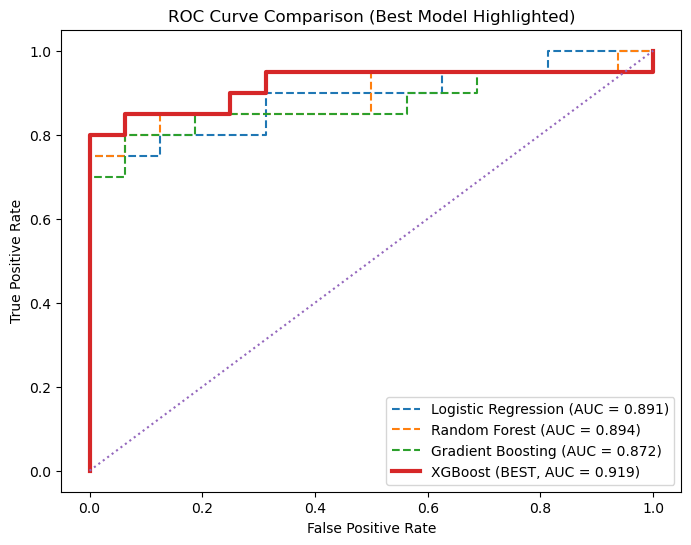

Best Model: XGBoost


In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

# Store results
models = {
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf,
    "Gradient Boosting": y_prob,
    "XGBoost": y_prob_xgb
}

roc_results = {}

# 🔹 Calculate ROC for all models
for name, y_prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_results[name] = (fpr, tpr, roc_auc)

# 🔥 Find best model
best_model = max(roc_results, key=lambda x: roc_results[x][2])

# 🔹 Plot all models
for name, (fpr, tpr, roc_auc) in roc_results.items():
    
    if name == best_model:
        # 🔥 Highlight best model
        plt.plot(
            fpr, tpr,
            linewidth=3,
            linestyle='-',
            label=f"{name} (BEST, AUC = {roc_auc:.3f})"
        )
    else:
        # Normal models
        plt.plot(
            fpr, tpr,
            linestyle='--',
            label=f"{name} (AUC = {roc_auc:.3f})"
        )

# 🔸 Random line
plt.plot([0, 1], [0, 1], linestyle=':')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Best Model Highlighted)")
plt.legend()

plt.show()

# 🏆 Print best model
print(f"Best Model: {best_model}")

## ROC Curve Analysis

- The ROC (Receiver Operating Characteristic) curve is used to evaluate the performance of classification models.

- It plots:
  - **True Positive Rate (TPR)** on the Y-axis  
  - **False Positive Rate (FPR)** on the X-axis  

- A model with a curve closer to the **top-left corner** indicates better performance.

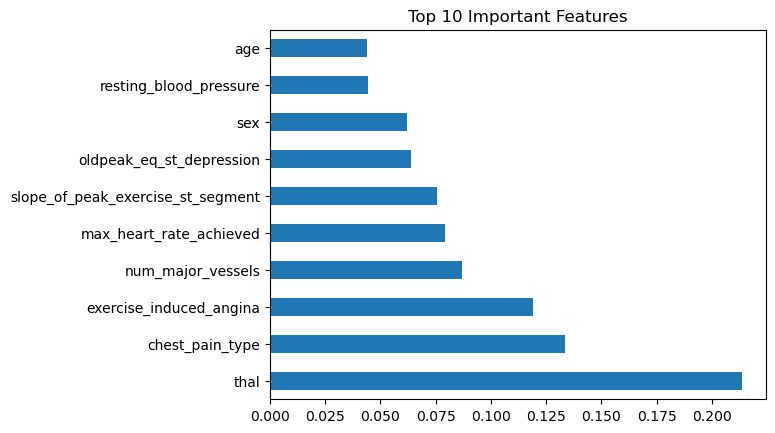

In [48]:
# Plot top features
import pandas as pd
# Get feature importances from pipeline model
importances = xgb_model.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [48]:
# ==========================================
# FINAL BEST MODEL SELECTION
# ==========================================
results_df = [
    lr_baseline, lr_tuned,
    rf_baseline, rf_tuned,
    gb_model,
    xgb_baseline, xgb_tuned
]

df = pd.DataFrame(results_df)

# Sort models by ROC-AUC
results_df = df.sort_values(by="ROC-AUC", ascending=False)

# Get best model row
best_model_row = results_df.iloc[0]

print("🏆 Best Model Selected:")
print(best_model_row)

🏆 Best Model Selected:
Model         XGBoost
Type            Tuned
ROC-AUC      0.921875
Accuracy     0.861111
Precision         1.0
Recall           0.75
F1 Score     0.857143
Name: 6, dtype: object


## Feature Importance

Identified key features influencing predictions
Improved model interpretability
Provided insights into important medical factors.

## Hyperparameter Tuning
Applied GridSearchCV / RandomizedSearchCV
Improved model performance through optimization

## Important Hyperparameters

n_estimators → number of trees

max_depth → tree depth

learning_rate → step size

subsample → fraction of data used

colsample_bytree → features used per tree

## CONCLUSION
After comparing all models, XGBoost (tuned) achieved the best performance. It provided the highest ROC-AUC score and handled complex relationships      in the data effectively.
Therefore, XGBoost was selected as the final model for heart disease prediction.
The final model can effectively predict heart disease risk and can assist healthcare professionals in early diagnosis and decision-making.”